In [1]:
from spatial_glmm_pkg import SpatialCustomLinkPQL, Poisson
import numpy as np

from scipy.special import expit, logit
from scipy.spatial.distance import cdist
from scipy.linalg import solve, cholesky, cho_solve, lstsq
from scipy.optimize import minimize
from scipy.stats import multivariate_normal

from sklearn.preprocessing import OneHotEncoder

import multiprocessing as mp
from functools import partial
import warnings, time

import matplotlib.pyplot as plt

In [3]:
from spatial_glmm_pkg import simulate_srt

# Simulate
Y, X, coords, truth = simulate_srt(
    true_beta=np.log([40, 20, 55]),
    a=-1.47,
    sigma2=0.2,
    rho=1.0,
    n=1000,
    seed=42
)

# Check what was generated
print(f"Group means: {[Y[truth['group']==k].mean() for k in range(3)]}")
print(f"Capture rate: {truth['p'].mean():.3f}")

# Fit
model = SpatialCustomLinkPQL(Y, X, a=-1.47, coords=coords, family=Poisson())
model.fit(
    init_sigma2=0.2,
    init_rho=1.0,
    init_random=truth['b'],
    init_beta=np.log(np.array([4.99]*3)/0.2),
    update_var_components_every=1,
    damping=0.5,
    tol=1e-5
)
model.summary()

Group means: [np.float64(7.48169014084507), np.float64(3.8680981595092025), np.float64(10.137931034482758)]
Capture rate: 0.194

Spatial Poisson Custom Link PQL
Observations: 1000
Covariates: 3 (no intercept)
Baseline 'a': mean=-1.470, std=0.000
Baseline probability: 0.187
Mean Y: 7.15
Initial sigma2=0.2000, rho=1.0000
Damping: 0.5

Iter   1: beta=[3.508 3.127 3.779], sigma2=1.0582, rho=10.0000, b: [-0.890, 1.160], std(b)=0.335
Iter   2: beta=[3.597 3.068 3.89 ], sigma2=1.2229, rho=10.0000, b: [-0.803, 1.094], std(b)=0.314
Iter   3: beta=[3.634 3.033 3.936], sigma2=1.2432, rho=10.0000, b: [-0.778, 1.077], std(b)=0.311
Iter   4: beta=[3.651 3.015 3.957], sigma2=1.2334, rho=10.0000, b: [-0.767, 1.069], std(b)=0.311
Iter   5: beta=[3.659 3.005 3.968], sigma2=1.2251, rho=10.0000, b: [-0.773, 1.064], std(b)=0.310
Iter   6: beta=[3.663 3.    3.973], sigma2=1.2208, rho=10.0000, b: [-0.777, 1.061], std(b)=0.310
Iter   7: beta=[3.666 2.998 3.976], sigma2=1.2189, rho=10.0000, b: [-0.779, 1.060],

In [2]:
n = 1000 
coords = np.random.uniform(0, 10, size=(n, 2))
dist_mat = cdist(coords, coords)

# Generate spatial random effect
true_sigma2 = 0.3
true_rho = 2.0

G_true = true_sigma2 * np.exp(-dist_mat / true_rho)
true_rand_fx = multivariate_normal.rvs(mean=np.zeros(n), cov=G_true)
print(np.mean(true_rand_fx))
true_rand_fx = true_rand_fx - np.mean(true_rand_fx)

# And expected tech effects
lin_prob_offset = -1.475
lin_prob = lin_prob_offset + true_rand_fx
true_tech = expit(lin_prob)

groups = np.random.choice(range(3), n).reshape(-1,1)

true_fixed_fx = np.array([np.log(40), np.log(20), np.log(55)])

ohe = OneHotEncoder(max_categories=3, sparse_output=False)
X = ohe.fit_transform(groups)

# Linear predictor
true_eta = X @ true_fixed_fx + np.log(expit(lin_prob_offset + true_rand_fx))
true_mu = np.exp(true_eta)

true_bio_means = np.exp(X @ true_fixed_fx)
# Generate observed counts
Y = np.random.poisson(true_mu)

init_beta=np.array([np.log(40), np.log(20), np.log(55)]) + 1.47

print(f"\nData summary:")
print(f"Y - mean: {np.mean(Y):.2f}, range: [{np.min(Y)}, {np.max(Y)}]")
print(f"mu - mean: {np.mean(true_mu):.2f}, range: [{np.min(true_mu):.2f}, {np.max(true_mu):.2f}]")

-0.03884386942215704

Data summary:
Y - mean: 7.45, range: [0, 39]
mu - mean: 7.57, range: [1.03, 32.39]


In [4]:
model_pois = SpatialCustomLinkPQL(
    Y, X,
    a=-1.47,
    coords=coords,
    family=Poisson(),
    verbose=True
)

model_pois.fit(
    init_sigma2=0.2,
    init_rho=1,
    init_random=true_rand_fx,
    init_beta=np.log(np.array([4.99]*3)/0.2),
    damping=0.5,
    max_iter=150,
    update_var_components_every=1,
    tol=1e-5
)

model_pois.summary()

NameError: name 'true_rand_fx' is not defined

(<Figure size 1800x500 with 3 Axes>,
 array([<Axes: title={'center': 'QQ Plot (Pearson Residuals)'}, xlabel='Theoretical quantiles', ylabel='Pearson residuals'>,
        <Axes: title={'center': 'Pearson residuals vs Fitted Values'}, xlabel='Fitted values (μ)', ylabel='Pearson residuals'>,
        <Axes: title={'center': 'Scale-Location Plot'}, xlabel='Fitted values (μ)', ylabel='√|Standardized residuals|'>],
       dtype=object))

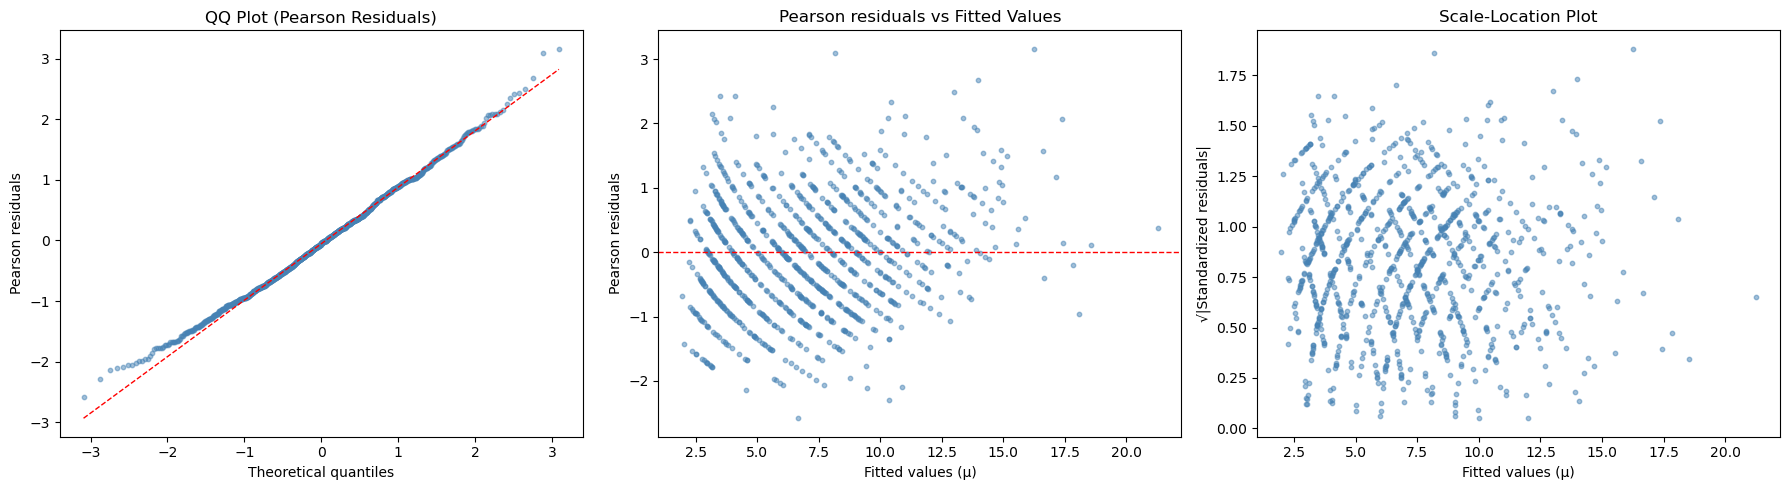

In [4]:
from spatial_glmm_pkg import diagnostics, spatial_summary

# diagnostics (QQ, residuals vs fitted, scale-location, histogram)
diagnostics(model)

# summary (observed, fitted, residuals, random effects, capture prob, QQ)
spatial_summary(model)

# Individual plots
# from spatial_glmm_pkg.plots import qq_plot, plot_random_effects, plot_residuals_spatial
# qq_plot(model_pois, residual_type='deviance')
# plot_random_effects(model_pois)
# plot_residuals_spatial(model_pois, residual_type='pearson')

In [3]:
from spatial_glmm_pkg import simulate_srt, SpatialCustomLinkPQL, Poisson

# Simulate
Y, X, coords, truth = simulate_srt(
    true_beta=np.log([40, 20, 55]),
    a=-1.47,
    sigma2=0.2,
    rho=1.0,
    n=1000,
    seed=42
)

# Check what was generated
print(f"Group means: {[Y[truth['group']==k].mean() for k in range(3)]}")
print(f"Capture rate: {truth['p'].mean():.3f}")

# Fit
model = SpatialCustomLinkPQL(Y, X, a=-1.47, coords=coords, family=Poisson())
model.fit(init_sigma2=0.2, init_rho=1.0, init_random=truth['b'],
          update_var_components_every=9999, damping=0.5)
model.summary()

Group means: [np.float64(7.48169014084507), np.float64(3.8680981595092025), np.float64(10.137931034482758)]
Capture rate: 0.194

Spatial Poisson Custom Link PQL
Observations: 1000
Covariates: 3 (no intercept)
Baseline 'a': mean=-1.470, std=0.000
Baseline probability: 0.187
Mean Y: 7.15
Initial sigma2=0.2000, rho=1.0000
Damping: 0.5


Converged in 56 iterations
Final beta: [3.6661 2.9942 3.9761]
Final b: mean=-0.000000, std=0.3209
Final sigma2=0.2000, rho=1.0000


Spatial Poisson Custom Link GLMM
Family: Poisson()
Converged: True (in 56 iterations)

Baseline 'a': -1.4700 (mean)
Spatial variance: sigma2 = 0.2000
Spatial range: rho = 1.0000

Fixed effects (no intercept):
  beta[0]: 3.6661
  beta[1]: 2.9942
  beta[2]: 3.9761

Random effects:
  mean: -0.000000 (should be ≈0)
  std:  0.3209
  range: [-0.7804, 1.0949]

Fitted values:
  mu: mean=7.15, range=[1.90, 21.71]
  p:  mean=0.1917, range=[0.0953, 0.4073]

Pearson dispersion: 0.7115


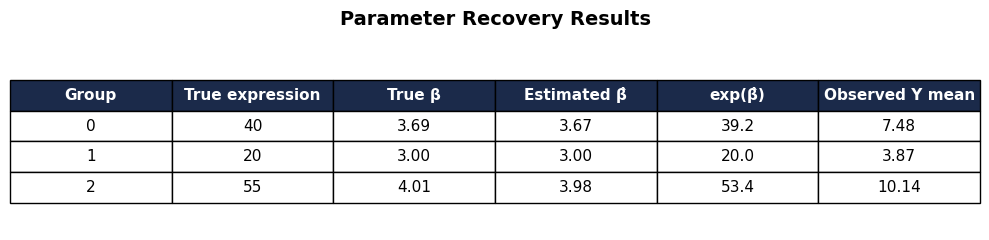

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Get observed Y means per group
group_means = []
for k in range(3):
    mask = X[:, k] == 1
    group_means.append(Y[mask].mean())

true_expression = [40, 20, 55]
true_beta = np.log(true_expression)
estimated_beta = model.beta
exp_beta = np.exp(estimated_beta)

# Build table data
table_data = []
for k in range(3):
    table_data.append([
        f"{k}",
        f"{true_expression[k]}",
        f"{true_beta[k]:.2f}",
        f"{estimated_beta[k]:.2f}",
        f"{exp_beta[k]:.1f}",
        f"{group_means[k]:.2f}"
    ])

col_labels = ["Group", "True expression", "True β", "Estimated β̂", "exp(β̂)", "Observed Y mean"]

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis('off')
table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)

# Style header row
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#1B2A4A')
    table[0, j].set_text_props(color='white', weight='bold')

plt.title("Parameter Recovery Results", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('parameter_recovery_table.png', dpi=200, bbox_inches='tight')
plt.show()